# Gradient descent and Newton's method

(This exercise originates from S. Boyd's course Convex Optimization)

Consider the unconstrained problem
  
  $$\begin{array}{ll}minimize\,\,\, f(x) = - \sum_{i=1}^m \log(1-a_i^T x)- \sum_{i=1}^n \log(1 - x_i^2),\end{array}$$
  
  with variable $x \in \mathbf{R}^n$, and $\mathbf{dom} f = \{x \;|\; a_i^Tx \le 1, ~i=1, \ldots, m, ~|x_i| \le 1, ~i=1, \ldots, n\}$. This is the problem of computing the analytic center of the set of linear inequalities
  
  $$a_i^Tx \leq 1, \quad i=1, \ldots, m, \qquad |x_i|\leq 1,\quad i=1, \ldots, n.$$
 
 Note that we can choose $x^{(0)}=0$ as our initial point. You can generate instances of this problem by choosing $a_i$ from some distribution on $\mathbf{R}^n$.
 

1. Use the gradient descent method to solve the problem. Use backtracking line search (BLS) to choose the step size and a stopping criterion of the form $\| \nabla f(x)\|_2^2 \leq \delta$. You need to choose the parameters $\alpha,\beta$ of BLS as well as $\delta$ in a reasonable way. Plot the objective function and step length versus iteration number. (Once you have determined $p^\star$ to high accuracy, you can also plot $f-p^\star$ versus iteration.) Experiment with the backtracking parameters $\alpha$ and $\beta$ to see their effect on the total number of iterations required. 
2. Repeat using Newton&#39;s method, again with BLS and this time with a stopping criterion based on the square $\lambda^2$ of Newton decrement. Produce the plots as for GD. Can you see the sharp distinction between the areas of slow and fast convergence for the Newton&#39;s method?

Some notes and tips:
* You can find the description of BLS in the slides for the Newton's method lecture. The exact same formulation can be used for GD.
* The domain of the objective is not $\mathbf{R}^n$. So, your BLS needs make sure that the chosen step length results in a point inside the domain (on top of satisfying the standard BLS condition). 
* You are going to have to find formulas for $\nabla f(x)$ and $\nabla^2 f(x)$ by hand using chain rule. If you really want to, you can use pytorch (or other similar tools) for this task, but it is probably not worth it. The GD code and the Newton code has to be your own.
* In the Newton's algorithm do not invert the Hessian, use ``numpy.linalg.solve`` (or other linear system solver) instead.

# Solution

## Objective Derivatives

$$ f(x) = - \sum_{k=1}^m \log(1-a_k^T x)- \sum_{i=1}^n \log(1 - x_i^2) $$

### Gradient

The formula for partial derivatives is:

$$ \frac{\partial f}{\partial x_i}(x) = \frac{2x_i}{1 - x_i^2} + \sum_{k=1}^m \frac{a_{ki}}{1-a_k^T x} $$

Hence, the gradient can be written as:

$$ \nabla f (x) = A^T \cdot d + b$$

where $A$ is an $m \times n$ matrix with $a_k^T$ as rows, $d$ is an $m$-dimensional column vector with $d_k = \frac{1}{1 - a_k^T x} > 0$ and $b$ is an $n$-dimensional column vector with $b_i = \frac{2x_i}{1 - x_i^2}$.


### Hessian

For $d(x)$ we have: 

$$ \frac{\partial d_i}{\partial x_j}(x) = \frac{a_{ij}}{(1 - a_i^Tx)^2} $$

which can be written in the matrix form as a Jacobian:

$$ J_d(x) = diag(\{d_i^2\}) A $$

Moreover for $b$, we have:

$$ \frac{\partial b_i}{\partial x_j}(x) = diag({\frac{2 + 2x_i^2}{(1 - x_i^2)^2}}) $$

Therefore:

$$ H_f = A^T diag(\{d_i^2\}) A + diag({\frac{2 + 2x_i^2}{(1 - x_i^2)^2}})$$

## Convexity of the Objective

Hessian can be rewritten as:

$$ H_f = \sum_i^m d_i^2 a_i a_i^T + diag({\frac{2 + 2x_i^2}{(1 - x_i^2)^2}}) $$

The sum part is a sum of positive semidefinite matrices, since $\forall v \in \mathbf{R}^n$:

$$ d_i^2 v^T (a_i a_i^T) v = d_i^2 ||v^T a_i||_2^2  \geq 0 $$

and therefore positive semidefinite.
The second term is a diagonal matrix with strictly positive terms, so it's stricly positive definite.
Hence $H_f \succ 0$ as a sum of a positive semidefinite (the sum part) and a strictly positive definite (the diagonal term) matrices.

# Programming Part

## Necessary imports

In [1]:
import numpy as np
import cvxpy as cp

## Custom implementation

In [2]:
m = 10000
n = 9000

A = np.random.rand(m, n)
x0 = np.zeros(n)

In [3]:
class ObjectiveFunction:
    def __init__(self, A):
        self.A = A
    
    def __call__(self, x):
        return -np.sum(np.log(1 - self.A @ x)) - np.sum(np.log(1 - np.square(x)))

    def gradient(self, x):
        return self.A.T @ (1 / (1 - self.A @ x)) + 2 * x / (1 - np.square(x))
    
    def hessian(self, x):
        d = 1 / (np.ones(self.A.shape[0]) - self.A @ x)
        D = np.diag(d**2)
        first_term = self.A.T @ D @ self.A
        second_term = np.diag(2 * (1 + np.square(x)) / (np.ones(self.A.shape[1]) - np.square(x))**2)
        return first_term + second_term

In [4]:
objective_function = ObjectiveFunction(A)

### General BLS

In [5]:
def bls(obj_func, x, search_direction, hard_max_step_size=1.0, softening_of_max_step_size = 0.99, alpha=0.5, beta=0.8):
    assert obj_func.gradient(x).T @ search_direction < 0, "incorrect search direction!"

    # A-related constraints
    #
    # We want:
    # A @ (x + max_step_size * search_direction) = A @ x + max_step_size * A @ search_driection <= 1
    # 
    # Hence we care only about these constraints for which a_i^T @ search_direction >= 0,
    # because only those can lead to violation of the constraints.

    nominators = 1 - obj_func.A @ x
    denominators = obj_func.A @ search_direction
    max_step_size = np.inf
    for i in range(len(denominators)):
        if denominators[i] <= 0:
            continue
        else:
            new_max_step_size_candidate = nominators[i] / denominators[i]
            if new_max_step_size_candidate < max_step_size:
                max_step_size = new_max_step_size_candidate

    # Box constraints
    #
    # |x_i + max_step_size * search_direction[i]| <= 1
    #
    # 1. If search_direction[i] > 0, we we solve:
    #
    # x_i + max_step_size * search_direction[i] <= 1
    #
    # which gives us:
    #
    # max_step_size <= (1 - x_i) / search_direction[i]
    #
    # 2. If search_direction[i] < 0, we can only decrease so we get a negative value on LHS, so:
    #
    # x_i + max_step_size * search_direction[i]| >= -1
    #
    # which gives us:
    #
    # max_step_size <= (-1 - x_i) / search_direction[i]

    for i in range(len(x)):
        if search_direction[i] > 0:
            new_max_step_size_candidate = (1 - x[i]) / search_direction[i]
        elif search_direction[i] < 0:
            new_max_step_size_candidate = (-1 - x[i]) / search_direction[i]
        else:
            new_max_step_size_candidate = np.inf
        
        if new_max_step_size_candidate < max_step_size:
            max_step_size = new_max_step_size_candidate

    step_size = np.min([hard_max_step_size, softening_of_max_step_size*max_step_size])
    
    while obj_func(x + step_size * search_direction) > obj_func(x) + alpha * step_size * np.dot(obj_func.gradient(x), search_direction):
        step_size = beta * step_size
    return step_size

### Gradient Descent BLS

In [6]:
def gd_bls(obj_func, x0, max_iters=1000, tol=1e-12, log_int = 100):
    x = x0.copy()

    stopping_criterions = []
    function_values = []
    step_sizes = []

    for i in range(max_iters):
        if i % log_int == 0:
            # print(f"iter: {i}, current x: {x}")
            ...
        gradient = obj_func.gradient(x)
        search_direction = -gradient
        function_values.append(obj_func(x))
        stopping_criterion = gradient.T @ gradient
        stopping_criterions.append(stopping_criterion)
        step_size = bls(obj_func, x, search_direction)
        step_sizes.append(step_size)
        x = x + step_size * search_direction
        if stopping_criterion < tol:
            break
    
    return x, stopping_criterions, function_values, step_sizes


In [7]:
x0 = np.zeros(n)

In [8]:

x_sol_gd, s_crs_gd, fun_vs_gd, step_sizes_gd = gd_bls(objective_function, x0)

In [9]:
objective_function(x_sol_gd)

np.float64(-74996.63867607692)

### Newton's BLS

In [10]:
def newton_bls(obj_func, x0, max_iters=1000, tol=1e-12, log_int = 100):
    x = x0.copy()

    stopping_criterions = []
    function_values = []
    step_sizes = []

    for i in range(max_iters):
        if i % log_int == 0:
            # print(f"iter: {i}, current x: {x}")
            ...
        gradient = obj_func.gradient(x)
        search_direction = -np.linalg.solve(obj_func.hessian(x), gradient)
        function_values.append(obj_func(x))
        lambda_sq_criterion = -gradient @ search_direction.T
        stopping_criterions.append(lambda_sq_criterion)
        step_size = bls(obj_func, x, search_direction)
        step_sizes.append(step_size)
        x = x + step_size * search_direction
        if lambda_sq_criterion < tol:
            break
    
    return x, stopping_criterions, function_values, step_sizes

In [11]:
x_sol_newton, s_crs_newton, fun_vs_newton, step_sizes_newton = newton_bls(objective_function, x0)

In [12]:
objective_function(x_sol_newton)

np.float64(-74996.63867607692)

### Plots

In [13]:
import matplotlib.pyplot as plt

In [14]:
steps_gd = range(len(s_crs_gd))
steps_newton = range(len(s_crs_newton))

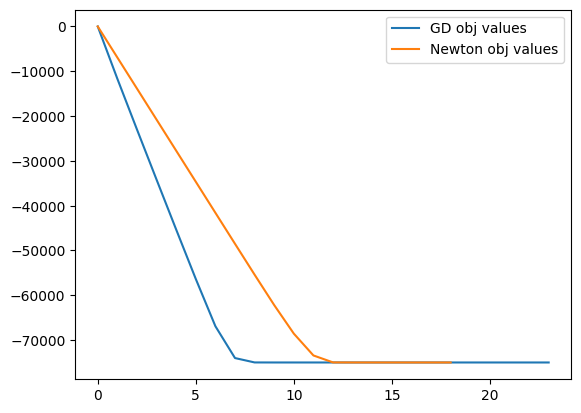

In [15]:
fig, ax = plt.subplots()

ax.plot(steps_gd, fun_vs_gd, label='GD obj values')
ax.plot(steps_newton, fun_vs_newton, label='Newton obj values')

ax.legend()


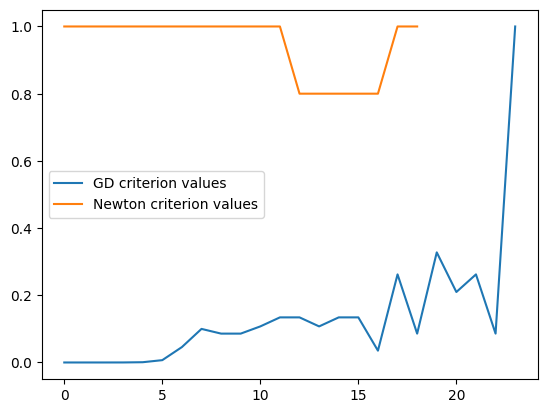

In [16]:
fig, ax = plt.subplots()

ax.plot(steps_gd, step_sizes_gd, label='GD criterion values')
ax.plot(steps_newton, step_sizes_newton, label='Newton criterion values')

ax.legend()

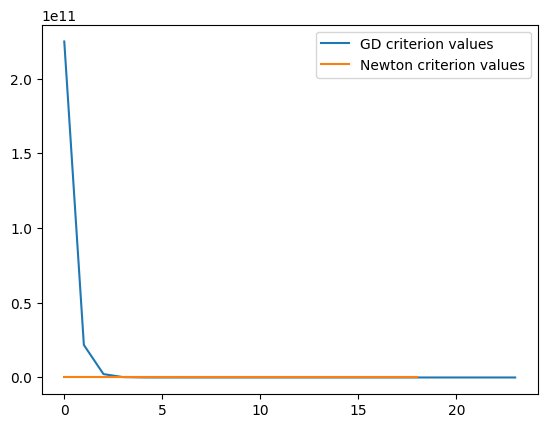

In [17]:
fig, ax = plt.subplots()

ax.plot(steps_gd, s_crs_gd, label='GD criterion values')
ax.plot(steps_newton, s_crs_newton, label='Newton criterion values')

ax.legend()


## Backtracking Line Search (BLS)

### Standard BLS algorithm (without domain constraints)

Given:
- Current point $x$
- Search direction $p$ (for GD: $p = -\nabla f(x)$; for Newton: $p = -(\nabla^2 f(x))^{-1} \nabla f(x)$)
- Parameters: $\alpha \in (0,1)$ (typically $0.01$ or $0.001$), $\beta \in (0,1)$ (typically $0.5$)

**Algorithm:**
```
t = 1
while f(x + t*p) > f(x) + alpha * t * grad_f(x)^T * p:
    t = beta * t
return t
```

The condition $f(x + t\cdot p) \leq f(x) + \alpha \cdot t \cdot \nabla f(x)^T p$ is the **Armijo condition**.
- LHS: value at the new point
- RHS: $f(x)$ plus a scaled predicted decrease (linear approximation scaled by $\alpha$)
- This ensures we're making "sufficient progress"

### BLS with domain constraints (our problem!)

Our domain is: $a_i^T x < 1$ for all $i=1,\ldots,m$, and $|x_j| < 1$ for all $j=1,\ldots,n$.

**Key insight:** Before checking Armijo, we must ensure $x + t\cdot p$ stays **inside the domain**.

**Algorithm:**

1. **Compute maximum feasible step size** $t_{\max}$:
   - For each linear constraint $a_i^T(x+tp) < 1$:
     - If $a_i^T p > 0$: upper bound is $t < \dfrac{1 - a_i^T x}{a_i^T p}$
     - If $a_i^T p \leq 0$: constraint is always satisfied (moving away from boundary)
   - For each box constraint $|x_j + tp_j| < 1$:
     - If $p_j > 0$: upper bound is $t < \dfrac{1 - x_j}{p_j}$
     - If $p_j < 0$: upper bound is $t < \dfrac{-1 - x_j}{p_j}$ (this is positive since $p_j < 0$)
     - If $p_j = 0$: no constraint
   - Set $t_{\max} = \min(\text{all bounds})$ (ensure $t_{\max} > 0$)

2. **Initialize step size:**
   ```
   t = min(1, 0.99 * t_max)  # slightly less than t_max to stay strictly inside
   ```

3. **Backtrack on Armijo condition:**
   ```
   while f(x + t*p) > f(x) + alpha * t * grad_f(x)^T * p  AND  t > t_min:
       t = beta * t
   ```
   where $t_{\min}$ is a small threshold (e.g., $10^{-6}$) to avoid infinite loops.

4. **Return** $t$ (or flag if $t < t_{\min}$ and Armijo not satisfied).

### Implementation notes

- **Strict vs. non-strict:** The domain uses $<$ (strict). In practice, stay slightly away from the boundary using factor $0.99$.
- **Gradient descent direction:** For GD, $p = -\nabla f(x)$, so $\nabla f(x)^T p = -\|\nabla f(x)\|_2^2 < 0$. The Armijo RHS becomes **negative**, guaranteeing $f$ decreases.
- **Parameters:** Smaller $\alpha$ and larger $\beta$ (closer to 1) are conservative; larger $\alpha$ and smaller $\beta$ are aggressive.


## `cvxpy` check

In [ ]:
x_cp = cp.Variable(n)

first_term_cp = -cp.sum(cp.log(np.ones(m) - A @ x_cp))
second_term_cp = -cp.sum(cp.log(np.ones(n) - cp.square(x_cp)))
objective_cp = cp.Minimize(first_term_cp + second_term_cp)

problem = cp.Problem(objective_cp)
problem.solve()

In [ ]:
problem.solution

Solution(optimal, {1: array([-0.5904966 , -0.59283082, -0.58651997, -0.59201884, -0.60227316,
       -0.60248933, -0.59639046, -0.59929566, -0.59709334, -0.60247444,
       -0.58919199, -0.59445416, -0.58860507, -0.59929976, -0.60130992,
       -0.59446671, -0.59989872, -0.59764053, -0.59627503, -0.59878008,
       -0.58626672, -0.60233841, -0.58353151, -0.60152765, -0.58495255,
       -0.59417181, -0.58708018, -0.59385345, -0.59564766, -0.59289754,
       -0.59295868, -0.5966655 , -0.60034897, -0.59954387, -0.59767155,
       -0.59522391, -0.59201714, -0.60267212, -0.58258932, -0.58855629,
       -0.5936189 , -0.59839681, -0.59983764, -0.59497304, -0.59959364,
       -0.59240674, -0.59055486, -0.59615444, -0.59797331, -0.60538617,
       -0.59716437, -0.59425083, -0.60994525, -0.58790647, -0.59027233,
       -0.59466598, -0.59151839, -0.60124689, -0.59789003, -0.60250479,
       -0.60080891, -0.60555592, -0.59514348, -0.59797581, -0.59192765,
       -0.59800183, -0.60001249, -0.594091